# Redes Neuronales Recurrentes (RNN) y LSTM para Predicción de Series Temporales
## 🎯 Objetivo del laboratorio

En este laboratorio exploramos el uso de Redes Neuronales Recurrentes (RNN) y Long Short-Term Memory (LSTM) para resolver problemas de series temporales, específicamente la predicción del consumo de energía eléctrica.

1. Introducción y entrenamiento de una RNN

2. Implementación matemática de una RNN desde cero

3. Comparación entre RNN y LSTM

4. Optimización de un modelo LSTM con hiperparámetros y regularización


## 📊 Actividad 1 Introducción y Comprensión de Redes Neuronales Recurrentes (RNN)


### 🧠 Concepto

Las Redes Neuronales Recurrentes (RNN) son modelos de aprendizaje profundo diseñados para procesar datos secuenciales.

A diferencia de redes neuronales tradicionales, las RNN poseen memoria interna, lo que les permite utilizar información pasada para realizar predicciones futuras.

In [24]:
# Importación de librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Herramientas para preprocesamiento y división de datos

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


In [25]:
# Cargar el dataset de consumo de energía
data = pd.read_csv('/home/jdvalmart/MachineDeepLearning/nivel_intermedio/household_power_consumption_small.csv')

# Crear una columna datetime combinando fecha y hora
data['datetime'] = pd.to_datetime(

    data.Date + ' ' + data.Time,
    dayfirst=True
)

print(data.head())

         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  01/01/2024  00:00:00                0.478                  0.116   242.95   
1  01/01/2024  01:00:00                0.562                  0.104   242.58   
2  01/01/2024  02:00:00                0.668                  0.157   239.74   
3  01/01/2024  03:00:00                0.701                  0.139   239.75   
4  01/01/2024  04:00:00                0.727                  0.176   239.34   

   Global_intensity            datetime  
0             1.862 2024-01-01 00:00:00  
1             2.290 2024-01-01 01:00:00  
2             2.489 2024-01-01 02:00:00  
3             2.868 2024-01-01 03:00:00  
4             2.985 2024-01-01 04:00:00  


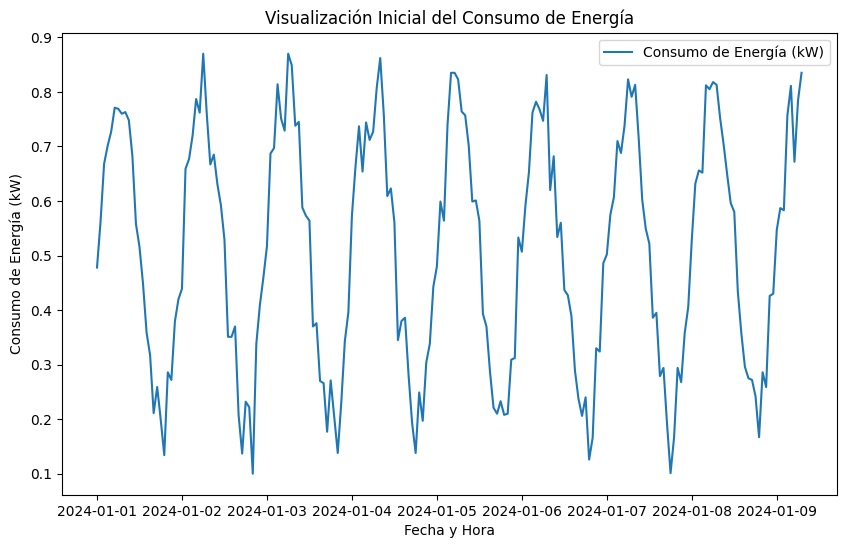

In [26]:
# Visualizar los primeros 1000 registros del consumo de energía

plt.figure(figsize=(10,6))

plt.plot(
    data['datetime'][:1000],
    data['Global_active_power'][:1000],
    label='Consumo de Energía (kW)'
)

plt.xlabel('Fecha y Hora')
plt.ylabel('Consumo de Energía (kW)')
plt.title('Visualización Inicial del Consumo de Energía')
plt.legend()

plt.show()

In [27]:
# Eliminar valores nulos del dataset
data = data.dropna()

# Mostrar el dataset limpio
display(data)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,datetime
0,01/01/2024,00:00:00,0.478,0.116,242.95,1.862,2024-01-01 00:00:00
1,01/01/2024,01:00:00,0.562,0.104,242.58,2.290,2024-01-01 01:00:00
2,01/01/2024,02:00:00,0.668,0.157,239.74,2.489,2024-01-01 02:00:00
3,01/01/2024,03:00:00,0.701,0.139,239.75,2.868,2024-01-01 03:00:00
4,01/01/2024,04:00:00,0.727,0.176,239.34,2.985,2024-01-01 04:00:00
...,...,...,...,...,...,...,...
195,09/01/2024,03:00:00,0.757,0.144,243.99,3.298,2024-01-09 03:00:00
196,09/01/2024,04:00:00,0.811,0.164,238.77,3.208,2024-01-09 04:00:00
197,09/01/2024,05:00:00,0.672,0.128,238.26,2.614,2024-01-09 05:00:00
198,09/01/2024,06:00:00,0.784,0.156,241.09,3.124,2024-01-09 06:00:00


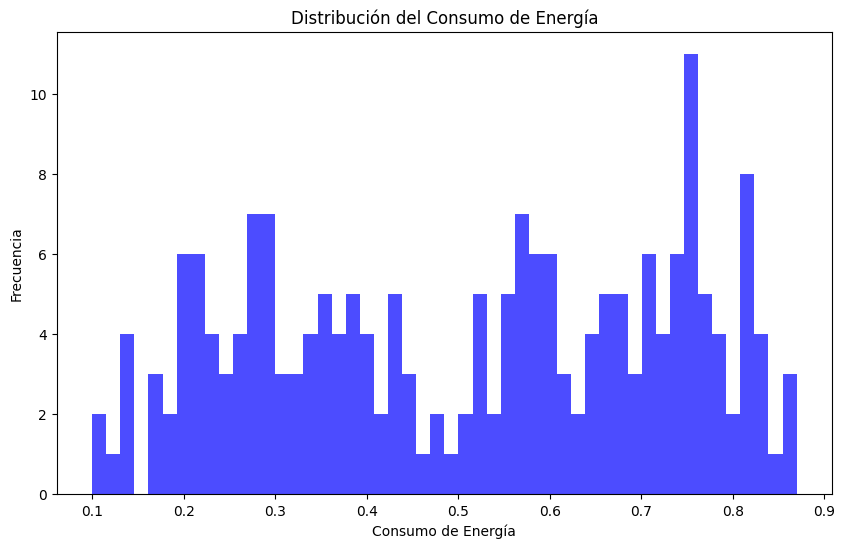

In [ ]:
#    Visualización de la distribución de los datos después de la normalización

plt.figure(figsize=(10,6))

plt.hist(
    data['Global_active_power'],
    bins=50,
    color='blue',
    alpha=0.7
)

plt.xlabel('Consumo de Energía')
plt.ylabel('Frecuencia')
plt.title('Distribución del Consumo de Energía')

plt.show()

### Definición y Entrenamiento de la RNN: 

Utilizaremos la librería TensorFlow para definir
una red neuronal recurrente sencilla. Esta red tendrá una capa de RNN y una capa de
salida que nos permitirá predecir el consumo de energía.

In [29]:
# Crear un objeto para normalizar datos entre 0 y 1
scaler = MinMaxScaler()

# Aplicar normalización al consumo de energía
data['Global_active_power'] = scaler.fit_transform(
    data[['Global_active_power']]
)

In [30]:
# Definir tamaño de la secuencia
sequence_length = 24

# Listas para almacenar secuencias
x_data = []
y_data = []

# Crear secuencias temporales
for i in range(len(data) - sequence_length):

    # Secuencia de entrada
    x_data.append(
        data['Global_active_power'].iloc[i:i+sequence_length].values
    )

    # Valor objetivo
    y_data.append(
        data['Global_active_power'].iloc[i+sequence_length]
    )

# Convertir listas a arrays
x_data = np.array(x_data)
y_data = np.array(y_data)

In [31]:
# División de los datos 80% entrenamiento y 20% pruebas
x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.2,
    random_state=42
)

In [32]:
# construción del modelo RNN 
'''Entrada -> RNN -> Dense -> Predicción
   -50 neronas recurrentes
   -ReLU como función de activación
'''

model = tf.keras.Sequential([

    # Capa RNN
    tf.keras.layers.SimpleRNN(
        50,
        activation='relu',
        input_shape=(x_train.shape[1],1)
    ),

    # Capa de salida
    tf.keras.layers.Dense(1)
])

/home/jdvalmart/MachineDeepLearning/venv_tf/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
#Compilación del modelo

model.compile(
    optimizer='adam',# optimizador eficiente
    loss='mse' # error cuadratico medio
)

In [34]:
# Entrenamiento -> el modelo aprende patrones del consumo energetico
model.fit(
    x_train,
    y_train,
    epochs=20,
    validation_data=(x_test,y_test)
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.2847 - val_loss: 0.1660
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2065 - val_loss: 0.1146
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1383 - val_loss: 0.0697
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0776 - val_loss: 0.0360
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0423 - val_loss: 0.0246
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0312 - val_loss: 0.0180
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0209 - val_loss: 0.0127
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0165 - val_loss: 0.0143
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0150 - val_loss: 0.0107
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0105 - val_loss: 0.0078
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0098 - val_loss: 0.0070
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0082 - val_loss: 0.0084
E

In [35]:
# Evaluación del modelo

loss = model.evaluate(x_test,y_test)

print(f"Error Cuadrático Medio: {loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0059
Error Cuadrático Medio: 0.005865077953785658


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


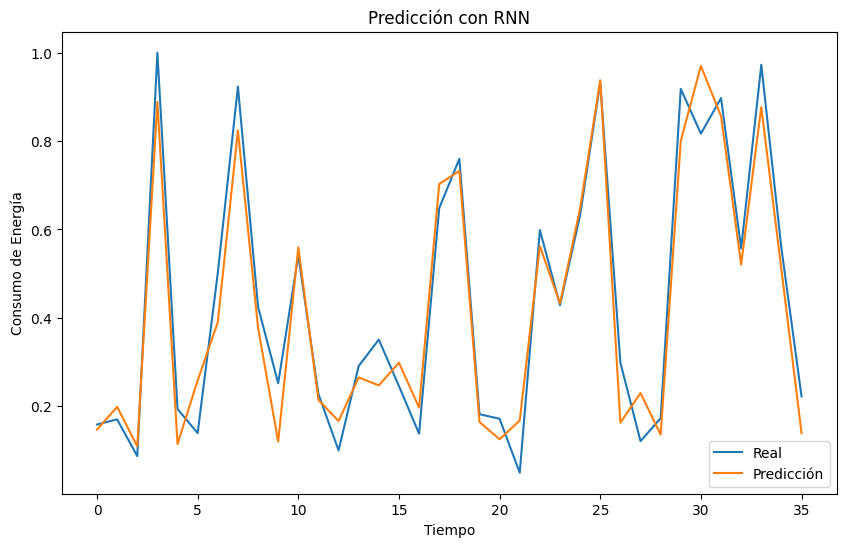

In [36]:
# Visualización de predicciones

y_pred = model.predict(x_test)

plt.figure(figsize=(10,6))

plt.plot(y_test,label="Real")
plt.plot(y_pred,label="Predicción")

plt.legend()
plt.xlabel("Tiempo")
plt.ylabel("Consumo de Energía")
plt.title("Predicción con RNN")

plt.show()

### Concluciones
Si el modelo aprendió correctamente:
 - la curva predicha seguirá el patrón de la real.
 - capturará picos de consumo.

## 📊 Actividad 2 Implementación Matemática de una RNN desde Cero

## 🧠 Objetivo

En esta actividad implementamos una RNN sin TensorFlow, utilizando únicamente NumPy.

### Esto permite entender:

- ecuación del estado oculto

- cálculo de gradientes

- Backpropagation Through Time (BPTT)

In [58]:
# Dataset de ejemplo

texto = "hola como estas"

In [59]:
# Creación del vocabulario

caracteres = list(set(texto))
n_caracteres = len(caracteres)

char_to_idx = {ch:i for i,ch in enumerate(caracteres)} # de caráter a indice
idx_to_char = {i:ch for i,ch in enumerate(caracteres)} # de indice a caráter

print(char_to_idx)

{'o': 0, 'h': 1, 'l': 2, 'm': 3, 't': 4, ' ': 5, 's': 6, 'c': 7, 'a': 8, 'e': 9}


In [60]:
# hiperparametros

n_hidden = 10 # Tamaño del estado oculto: un valor más alto permite a la red aprender representaciones más complejas, pero puede llevar a un sobreajuste.
learning_rate = 0.01 # Tasa de aprendizaje: controla el tamaño de los pasos en cada actualización. Un valor demasiado alto puede hacer que el modelo no converja, mientras que uno demasiado bajo puede hacer que el proceso sea muy lento.
epochs = 100 # Número de épocas: determina cuántas veces se procesará el conjunto de datos completo. Más épocas permiten aprender mejor, pero incrementan el riesgo de sobreajuste.

In [61]:
# inicialización de los pesos

W_xh = np.random.randn(n_hidden,n_caracteres) * 0.01
'''Inicializar los pesos con valores pequeños aleatorios
   para romper la simetría y garantizar que cada nodo aprenda
   características diferentes.'''
W_hh = np.random.randn(n_hidden,n_hidden) * 0.01
''' Pesos ocultos también se inicializan pequeños para evitar
    problemas de estabilidad durante el entrenamiento.'''
W_hy = np.random.randn(n_caracteres,n_hidden) * 0.01 # Inicialización pequeña para mejorar la convergencia del modelo.

b_h = np.zeros((n_hidden,1))
b_y = np.zeros((n_caracteres,1))

Utilizamos la función tanh porque tiene una salida en el rango de [-1, 1], lo cual ayuda a regularizar los valores y permite que la red
aprenda relaciones no lineales.

Además, su derivada tiene un efecto estabilizador en la propagación del gradiente, lo cual es útil para mitigar el problema de
desvanecimiento del gradiente.

La función softmax normaliza las salidas para que representen probabilidades, sumando siempre 1.

Esto es adecuado para la salida porque permite interpretar los valores como la probabilidad de cada clase.

In [62]:
# funciones de activación
def tanh(x):
    return np.tanh(x)

def softmax(x):

    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

In [63]:
# Guardar los errores por cada epoca
epoch_losses = []

for epoch in range(epochs):

    h_prev = np.zeros((n_hidden,1))
    total_loss = 0

    for t in range(len(texto)-1):
        # preparar entradas y objetivos
        x = np.zeros((n_caracteres,1))
        x[char_to_idx[texto[t]]] = 1

        target = char_to_idx[texto[t+1]]

        # Calculo del estado oculto y la salida
        h = tanh(
            np.dot(W_xh,x) +
            np.dot(W_hh,h_prev) +
            b_h
        )

        y = np.dot(W_hy,h) + b_y
        y_prob = softmax(y)

        # Retropropagación a través del tiempo (BPTT)
        dy = y_prob
        dy[target] -= 1
        dW_hy = np.dot(dy, h.T)
        db_y = dy
        dh = np.dot(W_hy.T, dy) + (1 - h ** 2) * np.dot(W_hh.T, h_prev)
        dW_xh = np.dot(dh, x.T)
        dW_hh = np.dot(dh, h_prev.T)
        db_h = dh

        # Actualizar pesos
        W_xh -= learning_rate * dW_xh
        W_hh -= learning_rate * dW_hh
        W_hy -= learning_rate * dW_hy
        b_h -= learning_rate * db_h
        b_y -= learning_rate * db_y

        # Actualizar el estado oculto anterior
        h_prev = h

    # Guardar el error total por época
    epoch_losses.append(total_loss)
    # Mostrar el error total por época
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss}")





Epoch 0, Loss: 0
Epoch 10, Loss: 0
Epoch 20, Loss: 0
Epoch 30, Loss: 0
Epoch 40, Loss: 0
Epoch 50, Loss: 0
Epoch 60, Loss: 0
Epoch 70, Loss: 0
Epoch 80, Loss: 0
Epoch 90, Loss: 0


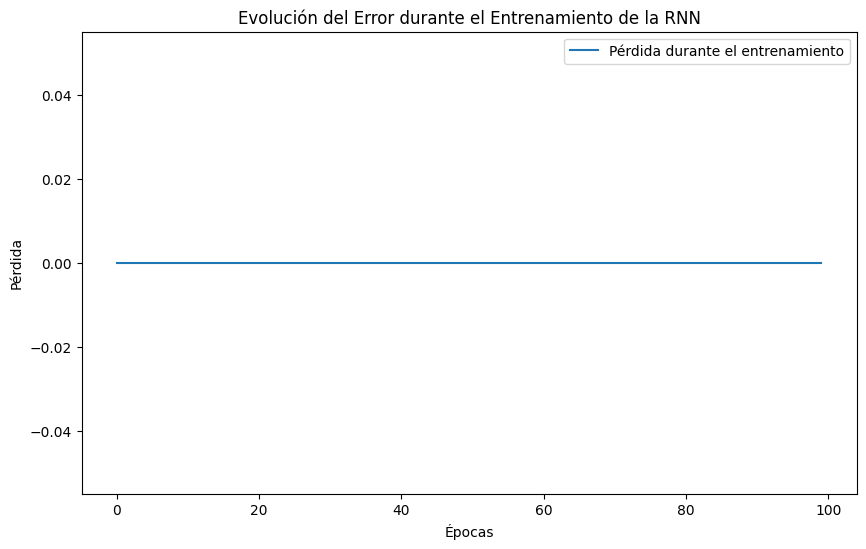

In [64]:
# Visualizar la evolución del error durante las épocas
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), epoch_losses, label='Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Evolución del Error durante el Entrenamiento de la RNN')
plt.legend()
plt.show()

## Actividad 3: Exploración y Entrenamiento de LSTM

implementar y entrenar una arquitectura de
Long Short-Term Memory (LSTM) utilizando una librería de deep learning, como TensorFlow o
PyTorch. Las LSTM son una variante de las Redes Neuronales Recurrentes (RNN) diseñadas
para abordar problemas de dependencias a largo plazo, lo cual las hace especialmente útiles
en tareas como la predicción de series temporales y el procesamiento de lenguaje natural.

In [ ]:
# Paso 1: Descargar y cargar los datos
# Use el archivo de datos que viene con la actividad
data = pd.read_csv('/home/jdvalmart/MachineDeepLearning/nivel_intermedio/household_power_consumption_small.csv')
data['datetime'] = pd.to_datetime(data.Date + ' ' + data.Time,
dayfirst=True)
data = data.dropna()


In [69]:
# Paso 2: Preprocesamiento de datos
data['Global_active_power'] = pd.to_numeric(data['Global_active_power'],
errors='coerce')
data = data.dropna()
scaler = MinMaxScaler()
data['Global_active_power'] = scaler.fit_transform(data[['Global_active_power']])
display(data)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,datetime
0,01/01/2024,00:00:00,0.490909,0.116,242.95,1.862,2024-01-01 00:00:00
1,01/01/2024,01:00:00,0.600000,0.104,242.58,2.290,2024-01-01 01:00:00
2,01/01/2024,02:00:00,0.737662,0.157,239.74,2.489,2024-01-01 02:00:00
3,01/01/2024,03:00:00,0.780519,0.139,239.75,2.868,2024-01-01 03:00:00
4,01/01/2024,04:00:00,0.814286,0.176,239.34,2.985,2024-01-01 04:00:00
...,...,...,...,...,...,...,...
195,09/01/2024,03:00:00,0.853247,0.144,243.99,3.298,2024-01-09 03:00:00
196,09/01/2024,04:00:00,0.923377,0.164,238.77,3.208,2024-01-09 04:00:00
197,09/01/2024,05:00:00,0.742857,0.128,238.26,2.614,2024-01-09 05:00:00
198,09/01/2024,06:00:00,0.888312,0.156,241.09,3.124,2024-01-09 06:00:00


In [77]:
# Crear secuencias para el entrenamiento
sequence_length = 24 # Predicción a partir de 24 horas previas
x_data, y_data = [], []
for i in range(len(data) - sequence_length):
    x_data.append(data['Global_active_power'].iloc[i:i +sequence_length].values)
    y_data.append(data['Global_active_power'].iloc[i + sequence_length])

x_data = np.array(x_data)
y_data = np.array(y_data)

# Dividir los datos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

# Paso 3: Definir y entrenar la RNN tradicional

model_rnn = tf.keras.Sequential(
    [
        tf.keras.layers.SimpleRNN(50, activation='relu',
        input_shape=(x_train.shape[1], 1)),
        tf.keras.layers.Dense(1)
    ])
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(
    x_train, y_train, epochs=20, validation_data=(x_test,y_test)
)

# Evaluación del modelo RNN
loss_rnn = model_rnn.evaluate(x_test, y_test)
print(f"Error Cuadrático Medio en el conjunto de prueba (RNN):{loss_rnn}")

# Paso 4: Definir y entrenar la LSTM
model_lstm = tf.keras.Sequential(
    [
        tf.keras.layers.LSTM(50, activation='relu',
        input_shape=(x_train.shape[1], 1)),
        tf.keras.layers.Dense(1)
    ])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(
    x_train, y_train, epochs=20, validation_data=(x_test, y_test))

# Evaluación del modelo LSTM
loss_lstm = model_lstm.evaluate(x_test, y_test)
print(f"Error Cuadrático Medio en el conjunto de prueba (LSTM):{loss_lstm}")

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.5555 - val_loss: 0.2919
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3543 - val_loss: 0.1846
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2196 - val_loss: 0.1068
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1190 - val_loss: 0.0493
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0532 - val_loss: 0.0285
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0347 - val_loss: 0.0326
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0337 - val_loss: 0.0231
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0240 - val_loss: 0.0164
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0186 - val_loss: 0.0153
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0176 - val_loss: 0.0149
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0165 - val_loss: 0.0135
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0144 - val_loss: 0.0120
E

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


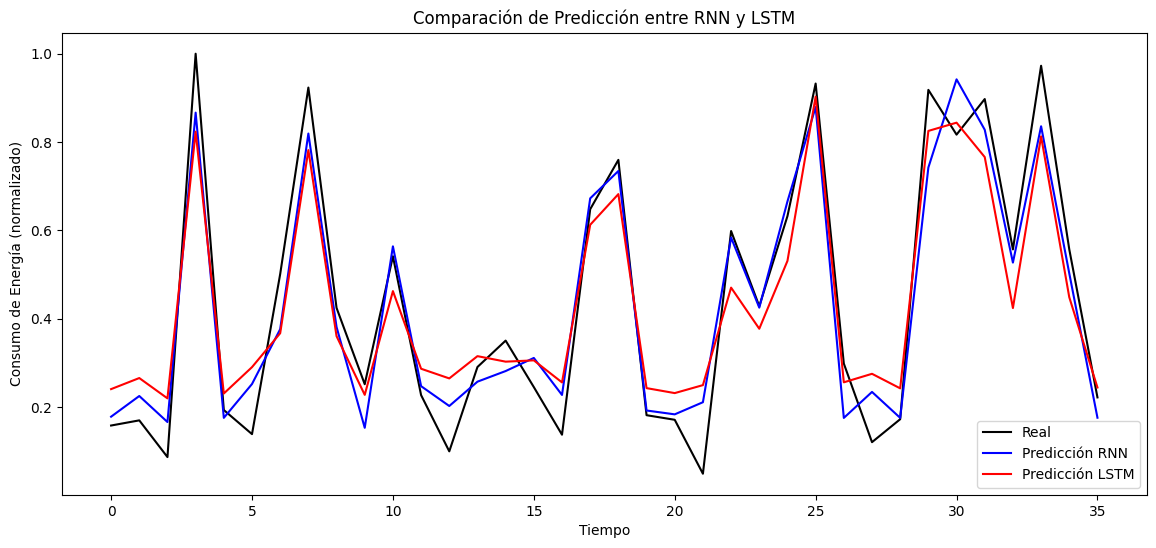

In [78]:
# Paso 5: Visualización de resultados
y_pred_rnn = model_rnn.predict(x_test)
y_pred_lstm = model_lstm.predict(x_test)
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Real', color='black')
plt.plot(y_pred_rnn, label='Predicción RNN', color='blue')
plt.plot(y_pred_lstm, label='Predicción LSTM', color='red')
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Consumo de Energía (normalizado)')
plt.title('Comparación de Predicción entre RNN y LSTM')
plt.show()

### Visualización del Proceso
En la gráfica de comparación, se muestra cómo la LSTM tiende a ser más precisa y estable que
la RNN tradicional al predecir la demanda energética. Las LSTM son capaces de manejar
dependencias a largo plazo gracias a sus puertas de entrada, olvido y salida, lo que les permite
retener información relevante durante más tiempo.

### Puertas de la LSTM

    ● Puerta de Entrada: Controla qué información de la entrada actual pasa al estado de la célula.
    ● Puerta de Olvido: Decide qué información del estado anterior debe olvidarse.
    ● Puerta de Salida: Determina qué parte del estado interno se utiliza para calcular la salida.
Estas puertas ayudan a las LSTM a superar los problemas de desvanecimiento y explosión de
gradientes, lo cual es una gran mejora respecto a las RNN tradicionales.

## Actividad 4: Análisis de Desempeño y
Consideraciones Prácticas para LSTM

### Introducción
En esta actividad, los estudiantes desarrollarán un modelo LSTM para abordar el problema de
la predicción de la demanda de energía y analizarán su desempeño utilizando métricas
adecuadas. Además, se discutirán estrategias para la selección de hiperparámetros, como el
tamaño de la secuencia y la tasa de aprendizaje, con el fin de optimizar el rendimiento del
modelo.

In [82]:
# Paso 2: Descargar y cargar los datos
# Use el archivo de datos que viene con la actividad
data = pd.read_csv('nivel_intermedio/household_power_consumption_small.csv')
data['datetime'] = pd.to_datetime(data.Date + ' ' + data.Time,
dayfirst=True)
data = data.dropna()

In [84]:
# Paso 3: Preprocesamiento de datos
data['Global_active_power'] = pd.to_numeric(data['Global_active_power'],
errors='coerce')
data = data.dropna()
scaler = MinMaxScaler()
data['Global_active_power'] = scaler.fit_transform(data[['Global_active_power']])

In [85]:
# Crear secuencias para el entrenamiento
sequence_length = 24 # Predicción a partir de 24 horas previas

x_data, y_data = [], []

for i in range(len(data) - sequence_length):
    x_data.append(data['Global_active_power'].iloc[i:i +sequence_length].values)
    y_data.append(data['Global_active_power'].iloc[i + sequence_length])
x_data = np.array(x_data)
y_data = np.array(y_data)

# Dividir los datos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data,
test_size=0.2, random_state=42)

In [88]:
# Definir el modelo LSTM con hiperparámetros ajustables
def create_lstm_model(sequence_length, learning_rate):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(50, activation='relu',
        input_shape=(sequence_length, 1)),
        tf.keras.layers.Dropout(0.2), # Aplicar dropout para mitigar el sobreajuste
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# Crear un modelo con un tamaño de secuencia de 24 y tasa de aprendizaje de 0.01
sequence_length = 24
learning_rate = 0.01
model_lstm = create_lstm_model(sequence_length, learning_rate)

# Implementar early stopping para detener el entrenamiento si no hay mejora en la pérdida de validación
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

In [89]:
# Entrenar el modelo LSTM
history = model_lstm.fit(x_train, y_train, epochs=50,
validation_data=(x_test, y_test), callbacks=[early_stopping])

# Evaluación del modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

# Hacer predicciones
y_pred = model_lstm.predict(x_test)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Métricas del modelo LSTM:\nMSE: {mse}\nMAE: {mae}\nR2: {r2}")

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.1870 - val_loss: 0.0691
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0903 - val_loss: 0.0680
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0780 - val_loss: 0.0544
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0568 - val_loss: 0.0681
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0655 - val_loss: 0.0605
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0546 - val_loss: 0.0493
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0494 - val_loss: 0.0460
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0480 - val_loss: 0.0451
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0470 - val_loss: 0.0456
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0429 - val_loss: 0.0409
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0423 - val_loss: 0.0388
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0388 - val_loss: 0.0363
E

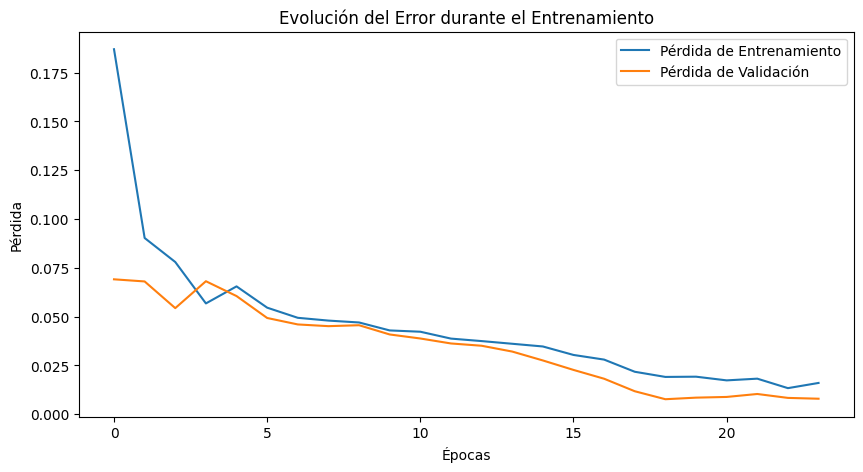

In [90]:
# Visualización de la evolución del error durante el entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Evolución del Error durante el Entrenamiento')
plt.legend()
plt.show()

## Conclusiones del Laboratorio
Al finalizar este laboratorio, se ha adquirido una comprensión profunda de
las RNN y LSTM, así como de sus aplicaciones en la predicción de series temporales.
Habrán desarrollado habilidades prácticas para implementar estos modelos y ajustar sus
hiperparámetros para mejorar el rendimiento. Además, serán capaces de evaluar y comparar
el desempeño de diferentes arquitecturas y comprender cómo técnicas como dropout y early
stopping pueden ayudar a mitigar problemas de sobreajuste.
Este conocimiento es fundamental para abordar problemas complejos en áreas como la previsión energética, la
economía y otros campos donde los datos temporales juegan un papel crucial.

## Referencias y Lecturas Complementarias

● Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
● Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. Neural Computation.
● Chollet, F. (2018). Deep Learning with Python. Manning Publications.
● Documentación oficial de TensorFlow: https://www.tensorflow.org/
● Artículos y tutoriales de Medium sobre el uso de LSTM y RNN en problemas de series temporales.